--- Basic Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 371 entries, 0 to 370
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   image          371 non-null    object 
 1   center_x       371 non-null    float64
 2   center_y       371 non-null    float64
 3   bbox_x         371 non-null    float64
 4   bbox_y         371 non-null    float64
 5   bbox_w         371 non-null    float64
 6   bbox_h         371 non-null    float64
 7   bbox_rotation  371 non-null    float64
 8   angle_deg      371 non-null    float64
dtypes: float64(8), object(1)
memory usage: 26.2+ KB
None

--- Summary Statistics ---
         center_x    center_y      bbox_x      bbox_y      bbox_w      bbox_h  \
count  371.000000  371.000000  371.000000  371.000000  371.000000  371.000000   
mean   412.728571  134.403504  391.625606  112.695687   42.011860   43.360377   
std     47.376397   47.414647   45.730218   47.349399    9.57396

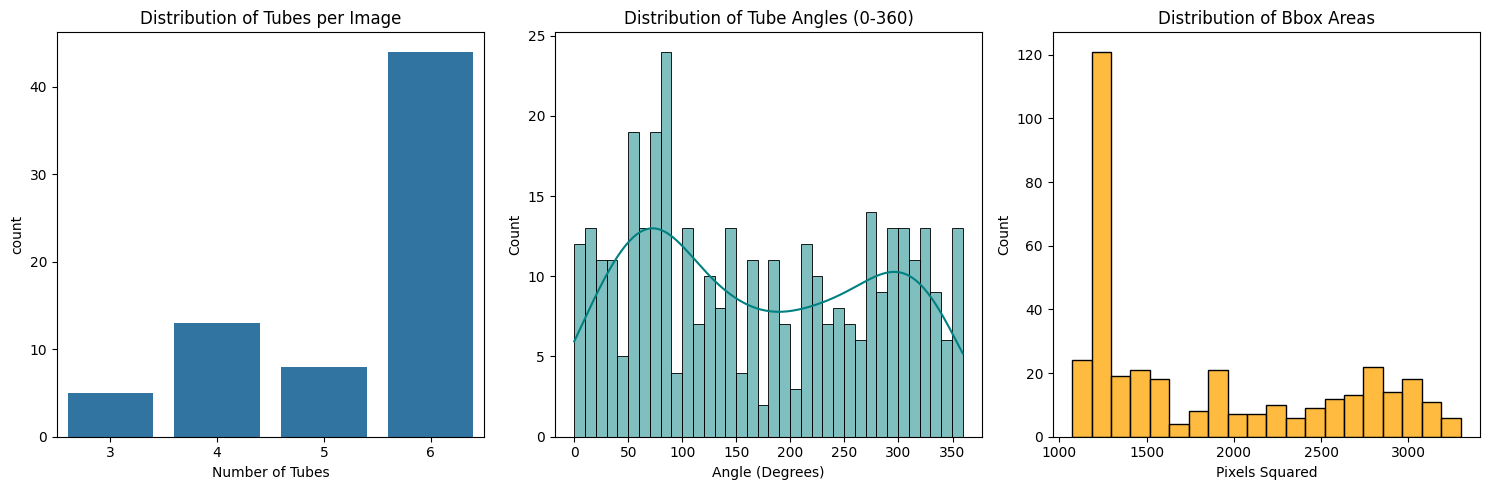

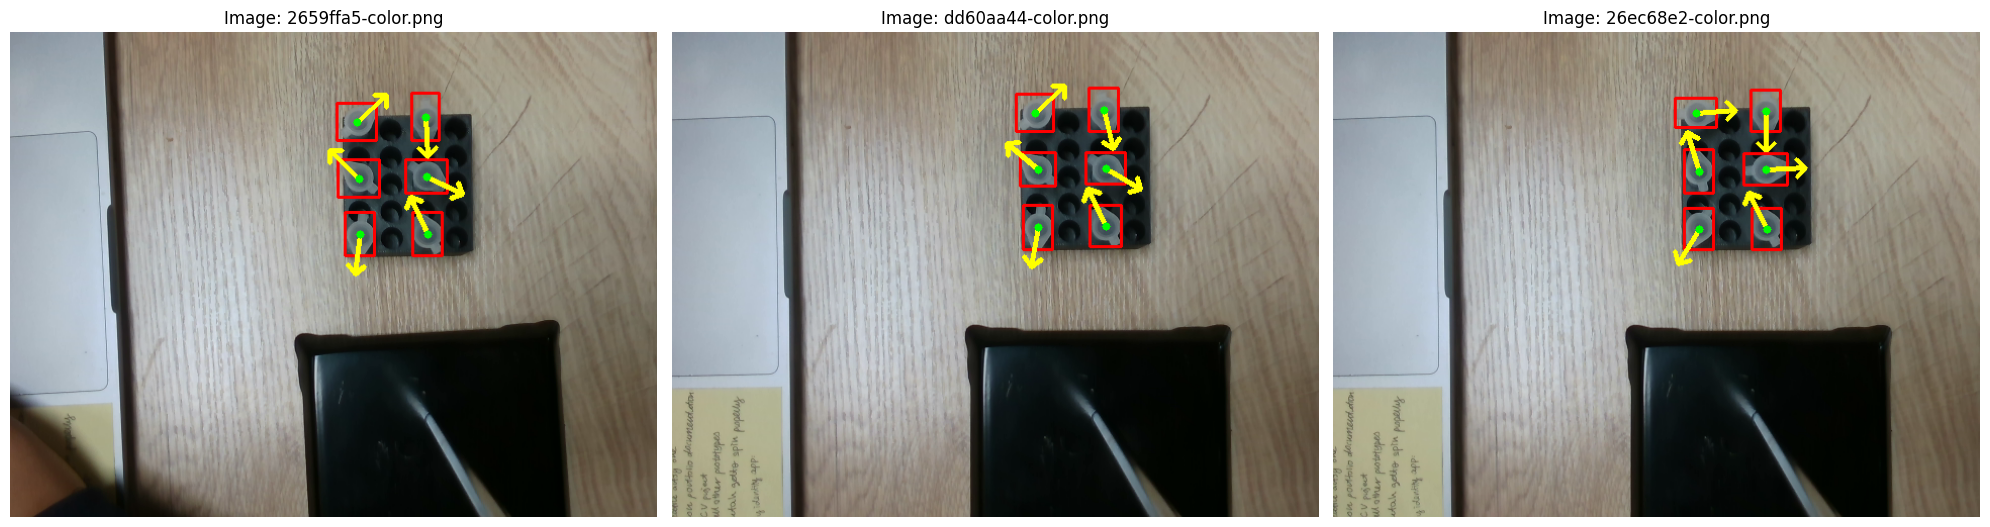

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import cv2
import os

# --- 1. Load Data ---
IMG_DIR = "/content/drive/MyDrive/TubeDetectionDataset_ZeonSystems2026/images"
ANNOT_PATH = "/content/drive/MyDrive/TubeDetectionDataset_ZeonSystems2026/annotations.csv"

df = pd.read_csv(ANNOT_PATH)

print("--- Basic Info ---")
print(df.info())
print("\n--- Summary Statistics ---")
print(df.describe())

# --- 2. Statistical Distributions ---
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
tube_counts = df.groupby('image').size()
sns.countplot(x=tube_counts)
plt.title('Distribution of Tubes per Image')
plt.xlabel('Number of Tubes')

# Angle Distribution
plt.subplot(1, 3, 2)
sns.histplot(df['angle_deg'], bins=36, kde=True, color='teal')
plt.title('Distribution of Tube Angles (0-360)')
plt.xlabel('Angle (Degrees)')

# Bounding Box Area
plt.subplot(1, 3, 3)
df['bbox_area'] = df['bbox_w'] * df['bbox_h']
sns.histplot(df['bbox_area'], bins=20, color='orange')
plt.title('Distribution of Bbox Areas')
plt.xlabel('Pixels Squared')

plt.tight_layout()
plt.show()

# --- 3. Visualization Function (Corrected) ---
def visualize_annotations(image_name, dataframe, img_dir):
    img_path = os.path.join(img_dir, image_name)
    image = cv2.imread(img_path)

    if image is None:
        print(f"Warning: Could not load image {img_path}")
        return np.zeros((480, 640, 3), dtype=np.uint8)

    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    # Filter rows for this image
    rows = dataframe[dataframe['image'] == image_name]

    for _, row in rows.iterrows():
        cx, cy = int(row['center_x']), int(row['center_y'])
        bw, bh = row['bbox_w'], row['bbox_h']
        rot = row['bbox_rotation'] # Clockwise
        angle_deg = row['angle_deg']

        rect = ((cx, cy), (bw, bh), rot)
        box = cv2.boxPoints(rect)
        box = np.int32(box)
        cv2.drawContours(image, [box], 0, (255, 0, 0), 2) # Blue Box

        length = 40
        angle_rad = np.deg2rad(angle_deg)
        end_x = int(cx + length * np.cos(angle_rad))
        end_y = int(cy - length * np.sin(angle_rad))

        # Draw the arrow
        cv2.arrowedLine(image, (cx, cy), (end_x, end_y), (255, 255, 0), 3, tipLength=0.3)
        cv2.circle(image, (cx, cy), 4, (0, 255, 0), -1)

    return image


# --- 4. Display Sample Images ---
sample_images = df['image'].unique()[:3]
fig, axes = plt.subplots(1, 3, figsize=(20, 10))

for i, img_name in enumerate(sample_images):
    annotated_img = visualize_annotations(img_name, df, IMG_DIR)
    axes[i].imshow(annotated_img)
    axes[i].set_title(f"Image: {img_name}")
    axes[i].axis('off')

plt.tight_layout()
plt.show()

In [ ]:
import pandas as pd
import numpy as np
import cv2
import os

# --- Configuration Paths ---
IMG_DIR = "/content/drive/MyDrive/TubeDetectionDataset_ZeonSystems2026/images"
ANNOT_PATH = "/content/drive/MyDrive/TubeDetectionDataset_ZeonSystems2026/annotations.csv"
OUTPUT_DIR = "/content/drive/MyDrive/TubeDetectionDataset_ZeonSystems2026/annotated_images"
os.makedirs(OUTPUT_DIR, exist_ok=True)

# --- 1. Load Data ---
print(f"Loading annotations from {ANNOT_PATH}...")
df = pd.read_csv(ANNOT_PATH)

unique_images = df['image'].unique()
print(f"Found {len(unique_images)} unique images to process. Starting generation...\n")

# --- 2. Process and Save Loop ---
success_count = 0

for img_name in unique_images:
    img_path = os.path.join(IMG_DIR, img_name)
    image = cv2.imread(img_path)

    if image is None:
        print(f"Warning: Could not read image {img_path}. Skipping.")
        continue

    tubes = df[df['image'] == img_name]

    for _, row in tubes.iterrows():
        cx, cy = int(row['center_x']), int(row['center_y'])
        bw, bh = row['bbox_w'], row['bbox_h']
        rot = row['bbox_rotation'] # Clockwise
        angle_deg = row['angle_deg']

        # --- Draw Bounding Box ---
        rect = ((cx, cy), (bw, bh), rot)
        box = cv2.boxPoints(rect)
        box = np.int32(box) # Using int32 for newer numpy versions
        cv2.drawContours(image, [box], 0, (255, 0, 0), 2)

        # --- Draw Orientation Vector (Joint to Tab) ---
        length = max(bw, bh) * 0.6
        angle_rad = np.deg2rad(angle_deg)

        end_x = int(cx + length * np.cos(angle_rad))
        end_y = int(cy - length * np.sin(angle_rad))

        cv2.arrowedLine(image, (cx, cy), (end_x, end_y), (0, 0, 255), 3, tipLength=0.3)
        cv2.circle(image, (cx, cy), 4, (0, 255, 0), -1)

    # --- Save Output ---
    out_path = os.path.join(OUTPUT_DIR, img_name)
    cv2.imwrite(out_path, image)
    success_count += 1

    # Print progress every 10 images
    if success_count % 10 == 0:
        print(f"Processed {success_count}/{len(unique_images)} images...")

print(f"\nDone! Successfully saved {success_count} annotated images to: {OUTPUT_DIR}")

Loading annotations from /content/drive/MyDrive/TubeDetectionDataset_ZeonSystems2026/annotations.csv...
Found 70 unique images to process. Starting generation...

Processed 10/70 images...
Processed 20/70 images...
Processed 30/70 images...
Processed 40/70 images...
Processed 50/70 images...
Processed 60/70 images...
Processed 70/70 images...

Done! Successfully saved 70 annotated images to: /content/drive/MyDrive/TubeDetectionDataset_ZeonSystems2026/annotated_images


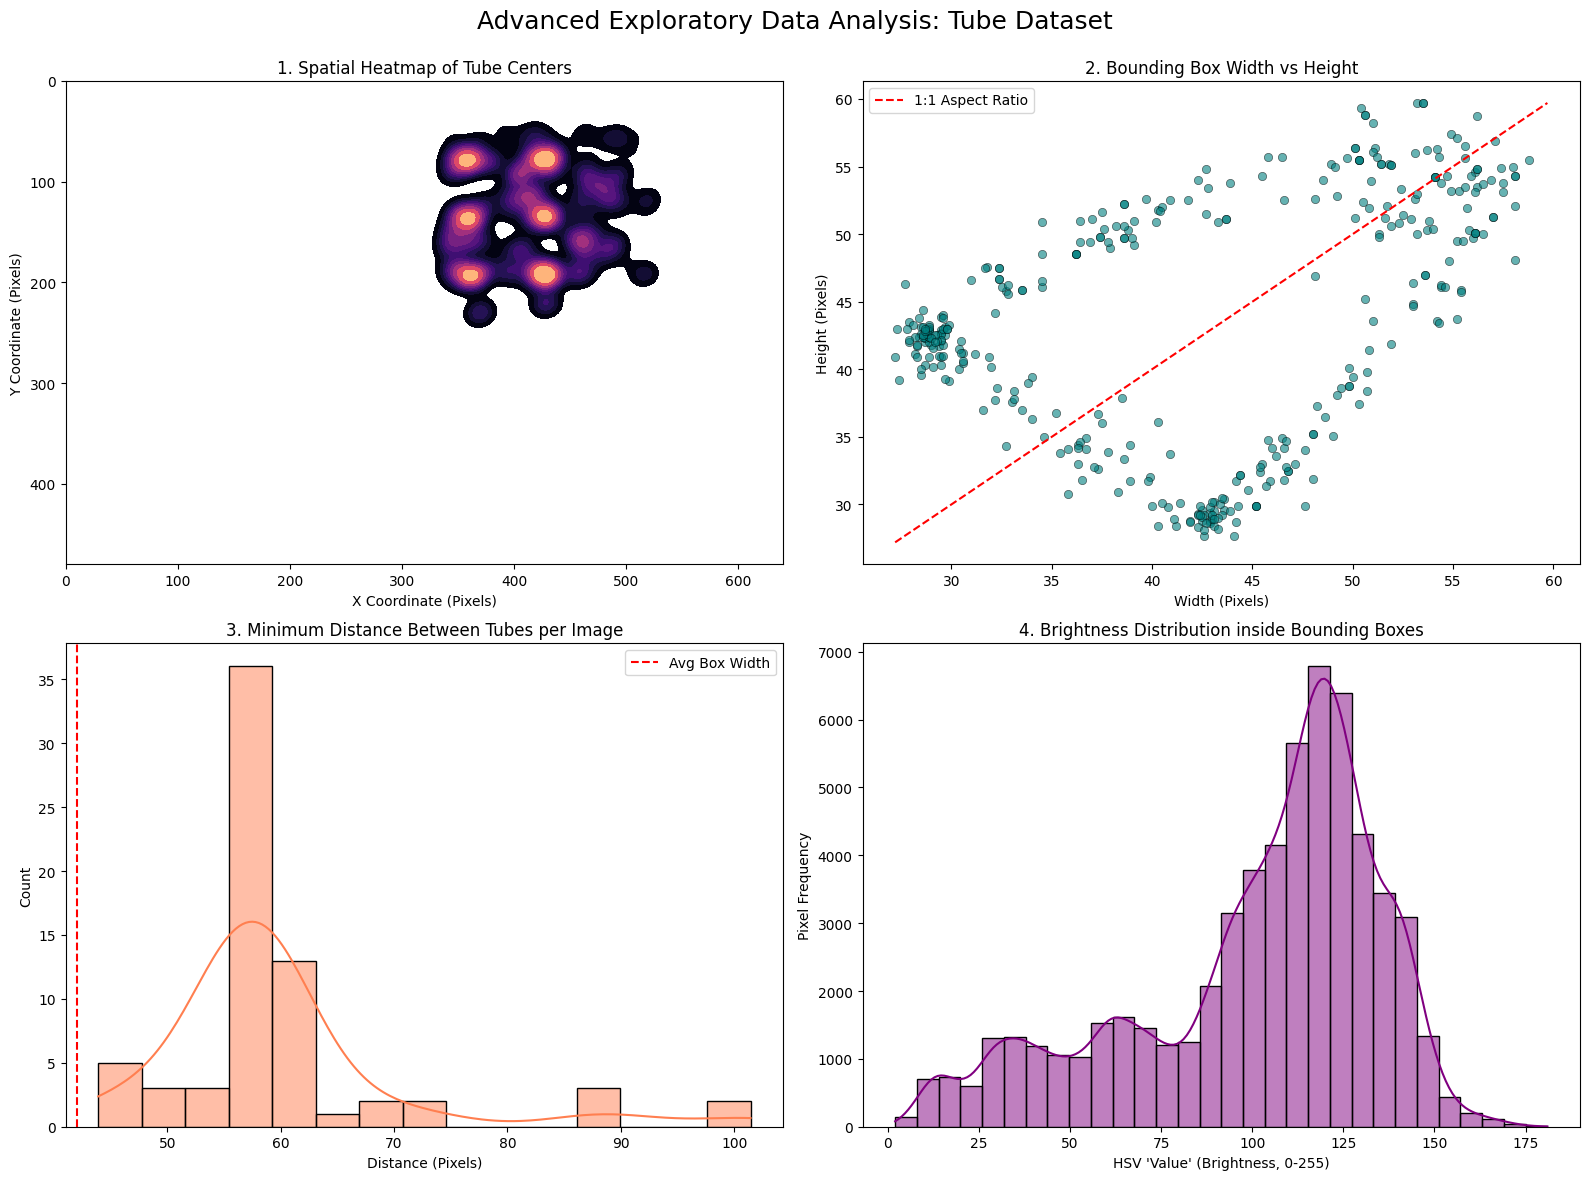

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import cv2
import os
from scipy.spatial.distance import pdist

# --- Configuration ---
IMG_DIR = "/content/drive/MyDrive/TubeDetectionDataset_ZeonSystems2026/images"
ANNOT_PATH = "/content/drive/MyDrive/TubeDetectionDataset_ZeonSystems2026/annotations.csv"
OUTPUT_DIR = "/content/drive/MyDrive/TubeDetectionDataset_ZeonSystems2026/annotated_images"

# Load Data
df = pd.read_csv(ANNOT_PATH)

# Set up the plotting grid
fig = plt.figure(figsize=(16, 12))
fig.suptitle("Advanced Exploratory Data Analysis: Tube Dataset", fontsize=18)

# ==========================================
# 1. Spatial Heatmap
# ==========================================
ax1 = plt.subplot(2, 2, 1)
sns.kdeplot(
    x=df['center_x'],
    y=df['center_y'],
    cmap="magma",
    fill=True,
    bw_adjust=0.5,
    ax=ax1
)
ax1.set_xlim(0, 640)
ax1.set_ylim(480, 0)
ax1.set_title("1. Spatial Heatmap of Tube Centers")
ax1.set_xlabel("X Coordinate (Pixels)")
ax1.set_ylabel("Y Coordinate (Pixels)")

# ==========================================
# 2. Aspect Ratio & Scale Variance
# ==========================================
ax2 = plt.subplot(2, 2, 2)
sns.scatterplot(
    x=df['bbox_w'],
    y=df['bbox_h'],
    alpha=0.6,
    color='teal',
    edgecolor='k',
    ax=ax2
)
min_val = min(df['bbox_w'].min(), df['bbox_h'].min())
max_val = max(df['bbox_w'].max(), df['bbox_h'].max())
ax2.plot([min_val, max_val], [min_val, max_val], 'r--', label='1:1 Aspect Ratio')

ax2.set_title("2. Bounding Box Width vs Height")
ax2.set_xlabel("Width (Pixels)")
ax2.set_ylabel("Height (Pixels)")
ax2.legend()

# ==========================================
# 3. Inter-Object Distance (Crowding)
# ==========================================
ax3 = plt.subplot(2, 2, 3)
min_distances = []

for img_name, group in df.groupby('image'):
    if len(group) > 1:
        # Extract centers
        centers = group[['center_x', 'center_y']].values
        # Calculate all pairwise distances
        distances = pdist(centers)
        # Record the minimum distance between any two tubes in this image
        min_distances.append(distances.min())

sns.histplot(min_distances, bins=15, color='coral', kde=True, ax=ax3)
ax3.axvline(x=df['bbox_w'].mean(), color='red', linestyle='--', label='Avg Box Width')
ax3.set_title("3. Minimum Distance Between Tubes per Image")
ax3.set_xlabel("Distance (Pixels)")
ax3.legend()

# ==========================================
# 4. Color Space Analysis (HSV)
# ==========================================
ax4 = plt.subplot(2, 2, 4)

h_vals, s_vals, v_vals = [], [], []

for _, row in df.head(50).iterrows():
    img_path = os.path.join(IMG_DIR, row['image'])
    if not os.path.exists(img_path):
        img_path = img_path.replace(".png", ".jpg")

    img = cv2.imread(img_path)
    if img is not None:
        hsv_img = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)

        x, y = int(row['bbox_x']), int(row['bbox_y'])
        w, h = int(row['bbox_w']), int(row['bbox_h'])

        crop = hsv_img[max(0, y):y+h, max(0, x):x+w]

        if crop.size > 0:
            h_vals.extend(crop[:,:,0].flatten())
            s_vals.extend(crop[:,:,1].flatten())
            v_vals.extend(crop[:,:,2].flatten())

sns.histplot(v_vals, bins=30, color='purple', kde=True, ax=ax4)
ax4.set_title("4. Brightness Distribution inside Bounding Boxes")
ax4.set_xlabel("HSV 'Value' (Brightness, 0-255)")
ax4.set_ylabel("Pixel Frequency")

plt.tight_layout()
plt.subplots_adjust(top=0.92)
plt.show()

In [3]:
!pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu121
!pip install ultralytics

Looking in indexes: https://download.pytorch.org/whl/cu121
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 32.6 MB/s eta 0:00:00


In [ ]:
from ultralytics import YOLO

model = YOLO('yolov8n-pose.pt')

# Train the model
results = model.train(
    data='/content/drive/MyDrive/TubeDetectionDataset_ZeonSystems2026/annotated_images/dataset.yaml',
    epochs=150,           # 150 passes over the data
    imgsz=640,            # Image size
    batch=8,              # Number of images per batch
    device=0,             # Use the GPU
    project='tube_detect',# Output folder name
    name='run_1'          # Output subfolder name
)

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Ultralytics 8.4.50 🚀 Python-3.12.13 torch-2.5.1+cu121 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/drive/MyDrive/TubeDetectionDataset_ZeonSystems2026/annotated_images/dataset.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=150, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freez

In [4]:
from ultralytics import YOLO
import pandas as pd
import numpy as np
import math
import os
from scipy.optimize import linear_sum_assignment

# --- Configuration ---
MODEL_PATH = "/content/best.pt"
IMG_DIR = "/content/drive/MyDrive/TubeDetectionDataset_ZeonSystems2026/images"
ANNOT_PATH = "/content/drive/MyDrive/TubeDetectionDataset_ZeonSystems2026/annotations.csv"
OUTPUT_DIR = "/content/drive/MyDrive/TubeDetectionDataset_ZeonSystems2026/annotated_images"

MATCH_THRESHOLD = 30.0

print("Loading model and data...")
model = YOLO(MODEL_PATH)
df = pd.read_csv(ANNOT_PATH)

# Tracking metrics
total_tp = 0
total_fp = 0
total_fn = 0
angle_errors = []

def get_angle_error(pred_deg, gt_deg):
    diff = abs(pred_deg - gt_deg)
    return min(diff, 360.0 - diff)

# --- Evaluation Loop ---
unique_images = df['image'].unique()
print(f"Evaluating on {len(unique_images)} images...\n")

for img_name in unique_images:
    gt_rows = df[df['image'] == img_name]
    gt_centers = gt_rows[['center_x', 'center_y']].values
    gt_angles = gt_rows['angle_deg'].values

    img_path = os.path.join(IMG_DIR, img_name)
    if not os.path.exists(img_path):
        img_path = img_path.replace(".png", ".jpg")

    results = model(img_path, verbose=False)[0]

    pred_centers = []
    pred_angles = []

    # 3. Extract Predictions
    if results.keypoints is not None and results.keypoints.xy.nelement() > 0:
        kpts = results.keypoints.xy.cpu().numpy()

        for kp_pair in kpts:
            cx, cy = kp_pair[0] # Keypoint 1: Center
            tx, ty = kp_pair[1] # Keypoint 2: Tab

            pred_centers.append([cx, cy])

            dx = tx - cx
            dy = cy - ty
            pred_angle_rad = math.atan2(dy, dx)
            pred_angle_deg = math.degrees(pred_angle_rad) % 360
            pred_angles.append(pred_angle_deg)

    pred_centers = np.array(pred_centers)

    # 4. Match Predictions to Ground Truth (Hungarian Algorithm)
    if len(pred_centers) == 0:
        total_fn += len(gt_centers)
        continue

    if len(gt_centers) == 0:
        total_fp += len(pred_centers)
        continue

    dist_matrix = np.linalg.norm(pred_centers[:, np.newaxis, :] - gt_centers[np.newaxis, :, :], axis=2)

    pred_indices, gt_indices = linear_sum_assignment(dist_matrix)

    matched_preds = set()
    matched_gts = set()

    for p_idx, g_idx in zip(pred_indices, gt_indices):
        if dist_matrix[p_idx, g_idx] <= MATCH_THRESHOLD:
            # Valid Match (True Positive)
            total_tp += 1
            matched_preds.add(p_idx)
            matched_gts.add(g_idx)

            # Calculate angle error
            error = get_angle_error(pred_angles[p_idx], gt_angles[g_idx])
            angle_errors.append(error)

    total_fp += len(pred_centers) - len(matched_preds)
    total_fn += len(gt_centers) - len(matched_gts)

# --- 6. Final Metrics Calculation ---
precision = total_tp / (total_tp + total_fp) if (total_tp + total_fp) > 0 else 0
recall = total_tp / (total_tp + total_fn) if (total_tp + total_fn) > 0 else 0
f1_score = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0
mean_angle_error = np.mean(angle_errors) if angle_errors else 0

print("====================================")
print("🎯 FINAL REPORT METRICS 🎯")
print("====================================")
print(f"Total True Positives : {total_tp}")
print(f"Total False Positives: {total_fp}")
print(f"Total False Negatives: {total_fn}")
print("------------------------------------")
print(f"Precision          : {precision:.4f}")
print(f"Recall             : {recall:.4f}")
print(f"F1 Score           : {f1_score:.4f}")
print(f"Mean Angle Error   : {mean_angle_error:.2f} degrees")
print("====================================")

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Loading model and data...
Evaluating on 70 images...

🎯 FINAL REPORT METRICS 🎯
Total True Positives : 371
Total False Positives: 0
Total False Negatives: 0
------------------------------------
Precision          : 1.0000
Recall             : 1.0000
F1 Score           : 1.0000
Mean Angle Error   : 12.97 degrees


Loading model from /content/best.pt...
Running inference on /content/drive/MyDrive/TubeDetectionDataset_ZeonSystems2026/annotated_images/images/val/043033e6-color.png...


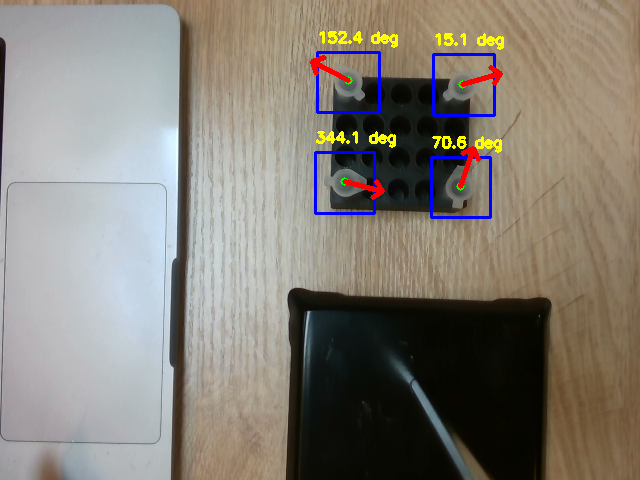

Success! Annotated image saved to annotated_output.jpg


In [5]:
from ultralytics import YOLO
import cv2
import math
import numpy as np
import sys
import os

from google.colab.patches import cv2_imshow

def annotate_image(model_path, image_path, output_path="annotated_output.jpg"):
    print(f"Loading model from {model_path}...")
    model = YOLO(model_path)

    print(f"Running inference on {image_path}...")

    # Read image
    img = cv2.imread(image_path)

    if img is None:
        print(f"Error: Could not load image at {image_path}")
        return

    # Run YOLO inference
    results = model(img, verbose=False)[0]

    # Check if anything was detected
    if results.keypoints is None or results.keypoints.xy.nelement() == 0:
        print("No tubes detected in the image.")
        return

    # Extract boxes and keypoints
    boxes = results.boxes.xyxy.cpu().numpy()   # [x1, y1, x2, y2]
    kpts = results.keypoints.xy.cpu().numpy()  # [[cx, cy], [tx, ty]]

    for i in range(len(boxes)):

        # 1. Get Coordinates
        x1, y1, x2, y2 = map(int, boxes[i])

        # Keypoints
        cx, cy = map(int, kpts[i][0])  # Center
        tx, ty = map(int, kpts[i][1])  # Tab

        # 2. Calculate Angle (0 to 360 CCW)
        dx = tx - cx
        dy = cy - ty

        angle_deg = math.degrees(math.atan2(dy, dx)) % 360

        # 3. Draw Bounding Box (Blue)
        cv2.rectangle(img, (x1, y1), (x2, y2), (255, 0, 0), 2)

        # 4. Draw Center Point (Green)
        cv2.circle(img, (cx, cy), 4, (0, 255, 0), -1)

        # 5. Draw Orientation Arrow (Red)
        length = 40

        end_x = int(cx + length * math.cos(math.radians(angle_deg)))
        end_y = int(cy - length * math.sin(math.radians(angle_deg)))

        cv2.arrowedLine(
            img,
            (cx, cy),
            (end_x, end_y),
            (0, 0, 255),
            3,
            tipLength=0.3
        )

        # 6. Put Angle Text
        text = f"{angle_deg:.1f} deg"

        cv2.putText(
            img,
            text,
            (x1, y1 - 10),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.5,
            (0, 255, 255),
            2
        )

    # Save image
    cv2.imwrite(output_path, img)

    # Display image directly
    cv2_imshow(img)

    print(f"Success! Annotated image saved to {output_path}")


# --- Run ---
if __name__ == "__main__":

    MODEL = "/content/best.pt"

    IMAGE = "/content/drive/MyDrive/TubeDetectionDataset_ZeonSystems2026/annotated_images/images/val/043033e6-color.png"

    annotate_image(MODEL, IMAGE)

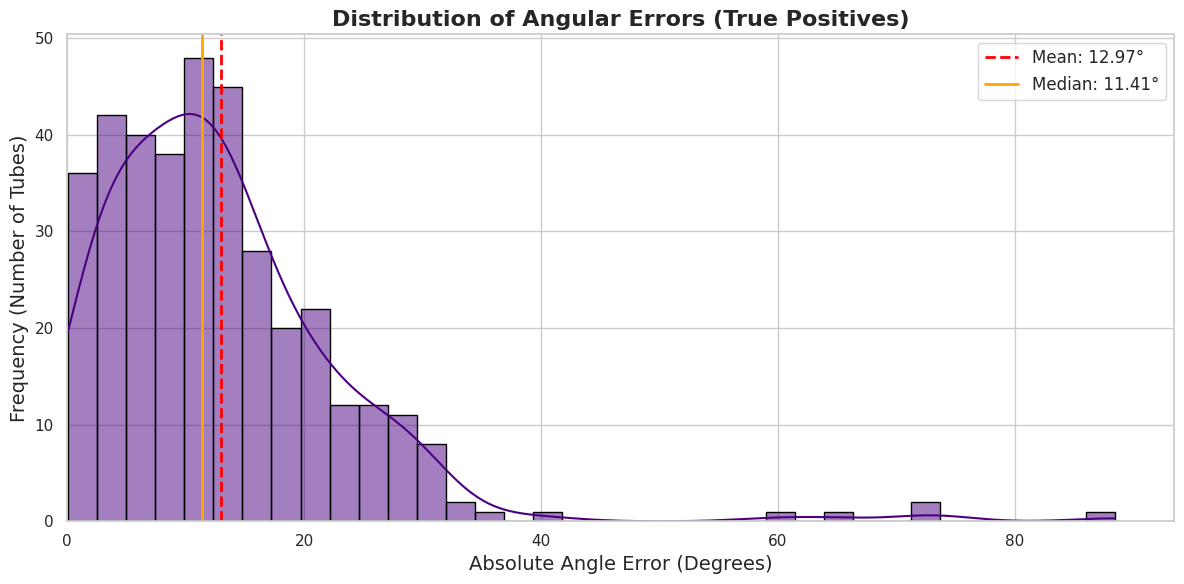

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Set up the plot style
plt.figure(figsize=(12, 6))
sns.set_theme(style="whitegrid")

# Plot the histogram with a KDE (Kernel Density Estimate) curve
sns.histplot(angle_errors, bins=36, kde=True, color='indigo', edgecolor='black')

# Calculate and draw the mean and median lines
mean_error = np.mean(angle_errors)
median_error = np.median(angle_errors)

plt.axvline(mean_error, color='red', linestyle='dashed', linewidth=2, label=f'Mean: {mean_error:.2f}°')
plt.axvline(median_error, color='orange', linestyle='solid', linewidth=2, label=f'Median: {median_error:.2f}°')

# Formatting
plt.title('Distribution of Angular Errors (True Positives)', fontsize=16, fontweight='bold')
plt.xlabel('Absolute Angle Error (Degrees)', fontsize=14)
plt.ylabel('Frequency (Number of Tubes)', fontsize=14)
plt.xlim(0, max(max(angle_errors) + 5, 45)) # Dynamic x-axis scaling
plt.legend(fontsize=12)

plt.tight_layout()
plt.show()